# YOLOv8 기반 제조 데이터 객체 탐지 실습

## 프로젝트 목표

이번 실습에서는 YOLOv8n을 이용해 shoes와 stamp 두 종류의 객체를 직접 학습하고 탐지 결과를 확인했습니다

교안에서 진행한 기본 학습과 평가에 더해서 데이터셋이 어떻게 구성되어 있는지 확인하고 클래스별 성능 차이와 입력 이미지 크기에 따른 성능 변화도 추가로 살펴봤습니다

단순히 모델을 실행하고 높은 mAP 값을 확인하는 것보다는 어떤 조건에서 결과가 달라지는지 직접 비교하면서 모델의 특성을 이해하는 것을 목표로 진행했습니다

## AI 도구 활용

Python 코드 작성과 오류를 해결하는 과정에서 ChatGPT를 보조 도구로 활용했습니다

코드를 그대로 복사해서 실행하기보다는 각 코드가 어떤 역할을 하는지 확인하고 직접 실행한 결과를 보면서 조건을 바꾸거나 결과를 해석했습니다


## 1. 실행 환경 확인

실습을 처음 진행할 때 Anaconda의 base 환경과 CV 환경이 섞이면서 PyTorch와 CUDA가 정상적으로 연결되지 않는 문제가 있었습니다

그래서 현재 Jupyter Notebook이 어떤 Python 환경을 사용하고 있는지 확인하고 CUDA와 GPU가 정상적으로 인식되는지 먼저 확인했습니다


In [2]:
import sys

print("Python version:", sys.version)
print("Python path:", sys.executable)

Python version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Python path: C:\Users\USER\anaconda3\python.exe


In [1]:
import sys
import torch

print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

Python: C:\Users\USER\.conda\envs\cv\python.exe
Torch: 2.14.0+cu130
CUDA: 13.0
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


### 환경 설정에서 확인한 점

처음에는 Anaconda base Python이 실행되고 있었지만 이후 CV CUDA 환경을 Jupyter Kernel로 연결했습니다

CUDA 사용 가능 여부가 True로 확인되었고 NVIDIA GeForce RTX 4050 Laptop GPU도 정상적으로 인식되었습니다

이후 학습에서는 GPU를 사용하기 위해 `device=0`으로 설정했습니다


In [2]:
from pathlib import Path

DATASET_DIR = Path(r"C:\Users\USER\Desktop\stamp.v10i.yolov8")
LOCAL_YAML = DATASET_DIR / "data_local.yaml"

print("dataset:", DATASET_DIR.exists())
print("yaml:", LOCAL_YAML.exists())

dataset: True
yaml: True


## 2. 데이터셋 특성 확인

모델의 성능만 확인하기보다 먼저 실제 학습 데이터가 어떻게 구성되어 있는지 살펴봤습니다

Train, Validation, Test 이미지의 개수와 클래스별 객체 수를 확인하고 Bounding Box의 크기도 함께 확인했습니다

특정 클래스의 데이터가 적거나 작은 객체가 많이 포함되어 있다면 클래스별 탐지 성능에도 영향을 줄 수 있다고 생각해 이후 결과와 함께 비교했습니다


In [ ]:
from pathlib import Path
from collections import Counter, defaultdict
import statistics
import yaml

IMAGE_EXTS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

def count_images(folder):
    folder = Path(folder)

    return sum(
        1
        for p in folder.rglob("*")
        if p.suffix.lower() in IMAGE_EXTS
    )

print("[데이터셋 크기]")

for split in ["train", "valid", "test"]:

    img_dir = DATASET_DIR / split / "images"
    label_dir = DATASET_DIR / split / "labels"

    print(
        f"{split:>5} : "
        f"{count_images(img_dir)} images / "
        f"{len(list(label_dir.glob('*.txt')))} label files"
    )


with open(
    LOCAL_YAML,
    "r",
    encoding="utf-8"
) as f:

    data_cfg = yaml.safe_load(f)


names = data_cfg.get(
    "names",
    ["shoes", "stamp"]
)

if isinstance(names, list):

    class_names = {
        i: name
        for i, name in enumerate(names)
    }

else:

    class_names = {
        int(k): v
        for k, v in names.items()
    }


class_count = Counter()
box_areas = defaultdict(list)

train_label_dir = (
    DATASET_DIR
    / "train"
    / "labels"
)


for txt_file in train_label_dir.glob("*.txt"):

    with open(
        txt_file,
        "r",
        encoding="utf-8"
    ) as f:

        for line in f:

            values = line.strip().split()

            if len(values) != 5:
                continue

            cls_id = int(float(values[0]))

            x, y, w, h = map(
                float,
                values[1:]
            )

            class_count[cls_id] += 1

            box_areas[cls_id].append(
                w * h
            )


print("\n[Train 클래스별 객체 수 및 Bounding Box 크기]")

for cls_id in sorted(class_count):

    areas = box_areas[cls_id]

    print(
        f"{class_names.get(cls_id, cls_id):>10} : "
        f"{class_count[cls_id]} objects | "
        f"평균 bbox 면적비 = "
        f"{statistics.mean(areas):.4f} | "
        f"중앙값 = "
        f"{statistics.median(areas):.4f}"
    )


In [ ]:
import matplotlib.pyplot as plt

labels = [
    class_names.get(i, str(i))
    for i in sorted(class_count)
]

values = [
    class_count[i]
    for i in sorted(class_count)
]

plt.figure(figsize=(6, 4))

plt.bar(
    labels,
    values
)

plt.title(
    "Train dataset class distribution"
)

plt.ylabel(
    "Number of objects"
)

plt.show()


all_areas = []

for areas in box_areas.values():
    all_areas.extend(areas)


plt.figure(figsize=(7, 4))

plt.hist(
    all_areas,
    bins=30
)

plt.title(
    "Normalized bounding box area distribution"
)

plt.xlabel(
    "bbox width x height"
)

plt.ylabel(
    "Count"
)

plt.show()


small_ratio = (
    sum(
        area < 0.02
        for area in all_areas
    )
    / len(all_areas)
)

print(
    "bbox 면적비가 0.02 미만인 객체 비율 : "
    f"{small_ratio:.1%}"
)


### 데이터 분석 결과에서 확인할 내용

위 결과를 통해 shoes와 stamp의 객체 수가 어느 정도 차이가 나는지 확인할 수 있습니다

또 Bounding Box 크기 분포를 통해 작은 객체가 많이 포함되어 있는지도 확인할 수 있습니다

이후 특정 클래스의 mAP가 상대적으로 낮게 나온다면 모델 자체의 문제뿐 아니라 데이터 개수나 객체 크기와 같은 데이터 특성도 같이 살펴볼 필요가 있다고 생각했습니다


In [3]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print("YOLOv8n loaded")

YOLOv8n loaded


## 3. YOLOv8n 사전학습 모델 사용

이번 실습에서는 처음부터 모델을 새로 학습하지 않고 COCO 데이터로 미리 학습된 YOLOv8n을 불러온 뒤 현재 데이터셋에 맞게 추가 학습했습니다

YOLOv8n은 YOLOv8 계열에서 비교적 작은 모델이라 학습과 추론 속도가 빠른 편이기 때문에 이번 실습의 기본 모델로 사용했습니다


In [4]:
train_results = model.train(
    data=str(LOCAL_YAML),
    epochs=20,
    imgsz=640,
    batch=16,
    name="stamp_detect",
    device=0,
    workers=0
)

Ultralytics 8.4.155  Python-3.12.14 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\USER\Desktop\stamp.v10i.yolov8\data_local.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, n

### 학습 조건

교안과 동일하게 20 Epoch, 입력 이미지 크기 640, Batch Size 16으로 학습했습니다

Windows의 Jupyter 환경에서 multiprocessing 관련 오류를 줄이기 위해 `workers=0`을 사용했습니다

학습 로그를 확인해보면 초반에 비해 Box Loss와 Classification Loss가 감소하고 Validation 성능이 높아지는 모습을 확인할 수 있었습니다

이후 평가는 마지막 Epoch의 모델이 아니라 학습 중 가장 좋은 성능으로 저장된 `best.pt`를 사용했습니다


In [ ]:
# 학습 과정에서 자동 생성된 그래프 확인

from pathlib import Path
from PIL import Image
from IPython.display import display

run_dir = Path(
    model.trainer.save_dir
)

print(
    "학습 결과 폴더 :",
    run_dir
)

plot_files = [
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "PR_curve.png"
]

for file_name in plot_files:

    file_path = (
        run_dir
        / file_name
    )

    if file_path.exists():

        print(
            "\n",
            file_name
        )

        display(
            Image.open(
                file_path
            )
        )


In [5]:
best_path = model.trainer.best
print("Best model:", best_path)

best_model = YOLO(best_path)

Best model: C:\Users\USER\runs\detect\stamp_detect\weights\best.pt


In [6]:
metrics = best_model.val(
    data=str(LOCAL_YAML),
    device=0,
    workers=0
)

Ultralytics 8.4.155  Python-3.12.14 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 126.019.0 MB/s, size: 27.8 KB)
val: Scanning C:\Users\USER\Desktop\stamp.v10i.yolov8\valid\labels.cache... 273 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 273/273  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 4.2it/s 4.2s0.2s
                   all        273        952       0.94       0.99      0.987      0.639
                 shoes        204        408      0.937       0.98      0.979      0.721
                 stamp        273        544      0.942          1      0.995      0.557
Speed: 0.8ms preprocess, 5.2ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to C:\Users\USER\runs\detect\val


## 4. Validation 결과 해석

Validation 결과 전체 Precision은 약 0.94, Recall은 약 0.99로 확인되었습니다

mAP@0.5는 약 0.987로 높게 나타났지만 더 엄격한 IoU 조건까지 포함하는 mAP@0.5:0.95는 약 0.639로 낮아졌습니다

이를 통해 객체 자체는 대부분 잘 찾지만 Bounding Box의 위치까지 더 엄격하게 평가하면 성능이 낮아질 수 있다는 것을 확인했습니다

또 shoes와 stamp의 클래스별 mAP에서도 차이가 나타났기 때문에 전체 결과 하나만 보기보다는 각 클래스의 결과를 따로 확인하는 것이 필요하다고 생각했습니다


In [ ]:
print("[Validation 결과 요약]")

for key, value in metrics.results_dict.items():

    try:
        print(
            f"{key:35s} : "
            f"{float(value):.4f}"
        )

    except:
        print(
            key,
            value
        )


print(
    "\n[클래스별 mAP@0.5:0.95]"
)

for cls_id, class_map in enumerate(
    metrics.box.maps
):

    name = best_model.names.get(
        cls_id,
        str(cls_id)
    )

    print(
        f"{name:>10} : "
        f"{class_map:.4f}"
    )


print(
    "\n[추론 속도]"
)

for key, value in metrics.speed.items():

    print(
        f"{key:>12} : "
        f"{value:.3f} ms/image"
    )


In [7]:
test_images = list((DATASET_DIR / "test" / "images").glob("*"))
print("Test images:", len(test_images))

results = best_model.predict(
    source=str(test_images[0]),
    conf=0.25,
    device=0
)

Test images: 193

image 1/1 C:\Users\USER\Desktop\stamp.v10i.yolov8\test\images\clip1_mp4-1007_jpg.rf.797cad76f7531b9a2ea20751d0ff114b.jpg: 640x640 3 shoess, 1 stamp, 25.7ms
Speed: 4.5ms preprocess, 25.7ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


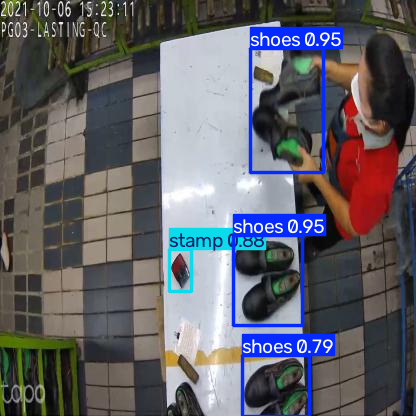

In [8]:
from PIL import Image
from IPython.display import display

annotated_img = results[0].plot()

annotated_img_rgb = annotated_img[:, :, ::-1]

display(Image.fromarray(annotated_img_rgb))


0: 640x640 3 shoess, 1 stamp, 40.1ms
1: 640x640 3 shoess, 2 stamps, 40.1ms
2: 640x640 5 shoess, 2 stamps, 40.1ms
3: 640x640 5 shoess, 2 stamps, 40.1ms
4: 640x640 6 shoess, 1 stamp, 40.1ms
Speed: 5.4ms preprocess, 40.1ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


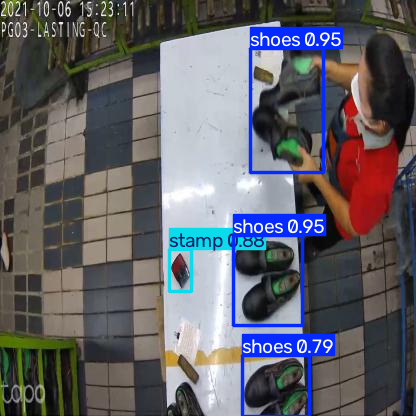

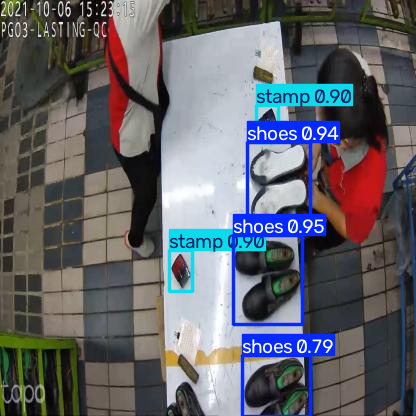

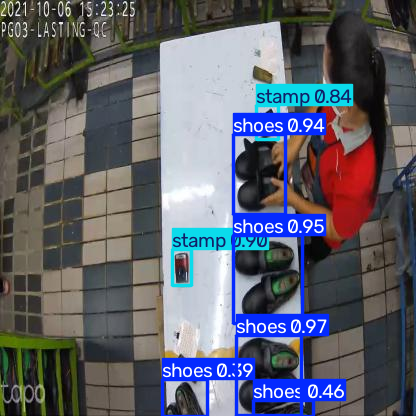

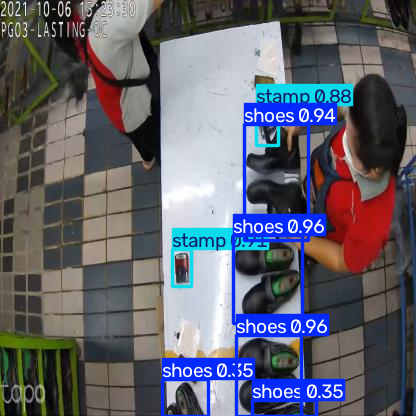

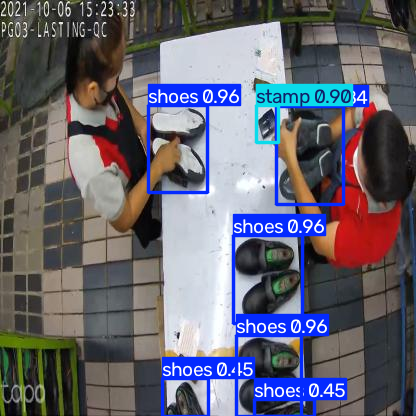

In [9]:
results = best_model.predict(
    source=[str(img) for img in test_images[:5]],
    conf=0.25,
    device=0
)

from PIL import Image
from IPython.display import display

for result in results:
    result_img = result.plot()
    display(Image.fromarray(result_img[:, :, ::-1]))

## 테스트 데이터 예측 결과

학습된 YOLOv8n 모델을 Test 이미지에 적용해서 실제 객체 탐지 결과가 어떻게 나타나는지 확인했습니다

Confidence 기준은 0.25로 설정했습니다

수치로 나온 성능뿐 아니라 실제 이미지에서 Bounding Box와 Confidence가 어떻게 표시되는지도 같이 확인했습니다


# 5. 추가 실험

교안의 기본 학습과 평가를 완료한 뒤 모델이 다른 조건에서도 비슷한 성능을 보이는지 추가로 확인했습니다

최고 성능 하나만 확인하기보다는 입력 조건을 바꿨을 때 정확도와 처리 속도가 어떻게 달라지는지를 직접 비교해보고 싶어 추가 실험을 진행했습니다


## 추가 실험을 위한 기존 best model 불러오기

기본 학습에서 저장된 `best.pt`를 다시 불러와 추가 실험에 사용했습니다

이미 완료한 20 Epoch 학습을 다시 반복하지 않고 동일한 모델을 이용해 조건만 변경하면서 결과를 비교했습니다


In [ ]:
from pathlib import Path
from ultralytics import YOLO

if "DATASET_DIR" not in globals():

    DATASET_DIR = Path(
        r"C:\Users\USER\Desktop\stamp.v10i.yolov8"
    )

    LOCAL_YAML = (
        DATASET_DIR
        / "data_local.yaml"
    )


if "best_model" not in globals():

    DEFAULT_BEST = (
        Path.home()
        / "runs"
        / "detect"
        / "stamp_detect"
        / "weights"
        / "best.pt"
    )

    if not DEFAULT_BEST.exists():

        raise FileNotFoundError(
            "기존 best.pt를 찾을 수 없습니다\n"
            "기본 학습 cell을 먼저 실행해주세요\n"
            f"예상 경로 : {DEFAULT_BEST}"
        )

    best_model = YOLO(
        str(DEFAULT_BEST)
    )

    print(
        "기존 best model 로드 완료 :",
        DEFAULT_BEST
    )


if "test_images" not in globals():

    IMAGE_EXTS = {
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".webp"
    }

    test_images = sorted(
        p
        for p in (
            DATASET_DIR
            / "test"
            / "images"
        ).glob("*")
        if p.suffix.lower()
        in IMAGE_EXTS
    )

print(
    "Test images :",
    len(test_images)
)


## 추가 실험 A — 입력 이미지 크기에 따른 정확도와 속도 비교

입력 이미지 크기가 모델의 정확도와 처리 속도에 어떤 영향을 주는지 확인하기 위해 416, 640, 832 세 가지 조건을 비교했습니다

입력 이미지가 작아지면 연산량이 줄어 속도가 빨라질 수 있지만 작은 객체의 정보가 줄어들 수도 있습니다

반대로 이미지가 커지면 세부 정보를 더 많이 사용할 수 있지만 계산량이 증가할 수 있습니다

그래서 동일한 모델을 이용해 각 이미지 크기에서 mAP와 inference time을 함께 비교했습니다


In [ ]:
import csv

ANALYSIS_DIR = (
    TARGET_DIR
    / "analysis_outputs"
)

ANALYSIS_DIR.mkdir(
    exist_ok=True
)


imgsz_values = [
    416,
    640,
    832
]

imgsz_results = []


for size in imgsz_values:

    print(
        "\n평가 중 : imgsz =",
        size
    )

    result = best_model.val(
        data=str(LOCAL_YAML),
        imgsz=size,
        device=0,
        workers=0,
        verbose=False,
        plots=False
    )

    imgsz_results.append(
        {
            "imgsz": size,

            "mAP50":
                float(
                    result.box.map50
                ),

            "mAP50_95":
                float(
                    result.box.map
                ),

            "inference_ms":
                float(
                    result.speed[
                        "inference"
                    ]
                )
        }
    )


print(
    "\n"
    f"{'imgsz':>7} | "
    f"{'mAP50':>8} | "
    f"{'mAP50-95':>10} | "
    f"{'infer ms':>10}"
)

print(
    "-" * 45
)


for row in imgsz_results:

    print(
        f"{row['imgsz']:7d} | "
        f"{row['mAP50']:8.4f} | "
        f"{row['mAP50_95']:10.4f} | "
        f"{row['inference_ms']:10.2f}"
    )


csv_path = (
    ANALYSIS_DIR
    / "imgsz_comparison.csv"
)


with open(
    csv_path,
    "w",
    newline="",
    encoding="utf-8-sig"
) as f:

    writer = csv.DictWriter(
        f,
        fieldnames=[
            "imgsz",
            "mAP50",
            "mAP50_95",
            "inference_ms"
        ]
    )

    writer.writeheader()

    writer.writerows(
        imgsz_results
    )


best_accuracy = max(
    imgsz_results,
    key=lambda x:
        x["mAP50_95"]
)

fastest = min(
    imgsz_results,
    key=lambda x:
        x["inference_ms"]
)


print(
    "\n가장 높은 mAP50-95 :",
    best_accuracy
)

print(
    "가장 빠른 조건 :",
    fastest
)

print(
    "CSV 저장 :",
    csv_path
)


### 입력 크기 비교 결과에서 확인할 점

결과에서는 mAP가 가장 높은 조건만 고르기보다 정확도가 얼마나 좋아지는지와 추론 시간이 얼마나 증가하는지를 같이 확인하려고 했습니다

실제 생산라인처럼 빠른 판단이 필요한 환경에서는 약간의 정확도 차이보다 처리 속도가 더 중요할 수도 있습니다

반대로 작은 객체를 정확하게 찾아야 하는 경우에는 처리 시간이 조금 길어지더라도 더 큰 입력 이미지를 사용하는 것이 도움이 될 수 있다고 생각했습니다


## 추가 실험 B — 모델이 상대적으로 확신하지 못한 사례 확인

전체 mAP만으로는 모델이 실제 어떤 이미지에서 판단을 어려워하는지 알기 어렵다고 생각했습니다

그래서 Test 이미지 중에서 상대적으로 Confidence가 낮게 나온 사례를 따로 확인했습니다

낮은 Confidence가 바로 오탐이라는 의미는 아니지만 모델이 상대적으로 확신하지 못한 상황을 직접 살펴보면서 공통적인 특징이 있는지 확인하기 위한 실험입니다


In [ ]:
from PIL import Image
from IPython.display import display

inspect_images = test_images[:60]


inspect_results = best_model.predict(
    source=[
        str(p)
        for p
        in inspect_images
    ],
    conf=0.05,
    imgsz=640,
    device=0,
    verbose=False
)


scored = []


for path, result in zip(
    inspect_images,
    inspect_results
):

    if len(result.boxes) > 0:

        avg_conf = float(
            result.boxes.conf
            .mean()
            .cpu()
        )

    else:

        avg_conf = 0.0


    scored.append(
        (
            avg_conf,
            path,
            result
        )
    )


scored.sort(
    key=lambda x:
        x[0]
)


print(
    "상대적으로 Confidence가 낮은 사례"
)


for rank, (
    avg_conf,
    path,
    result
) in enumerate(
    scored[:6],
    start=1
):

    print(
        f"\n{rank}. "
        f"{path.name}"
    )

    print(
        "평균 confidence :",
        round(
            avg_conf,
            3
        )
    )

    print(
        "탐지 객체 수 :",
        len(result.boxes)
    )


    result_img = (
        result.plot()
    )

    display(
        Image.fromarray(
            result_img[
                :,
                :,
                ::-1
            ]
        )
    )


### 결과를 보고 느낀 점

위 이미지들은 모델이 상대적으로 낮은 Confidence를 보인 사례입니다

이미지를 직접 확인한 뒤 객체가 가려져 있었는지, 크기가 작았는지, 화면의 가장자리에 있었는지 등 공통적인 특징이 있는지 확인해보려고 했습니다

실제 결과를 본 뒤 이 부분에는 제가 확인한 특징을 추가해서 정리할 예정입니다


# 6. 실험의 한계

입력 이미지 크기 비교에서는 하나의 학습된 모델을 사용하고 Validation 단계에서 이미지 크기만 변경했습니다

따라서 각각의 이미지 크기로 모델을 처음부터 다시 학습한다면 결과가 달라질 수 있습니다

또 Confidence가 낮은 이미지를 확인한 실험은 모델이 어려워하는 사례를 직접 살펴보기 위한 정성적인 분석이며 Ground Truth를 이용해 오류를 정확하게 분류한 실험은 아닙니다

이번 추가 실험은 모델의 성능을 완전히 검증하기보다는 모델이 어떤 조건에서 결과가 달라질 수 있는지 확인하는 과정으로 진행했습니다


# 7. 동료 피드백 및 반영

현재까지 별도로 기록한 동료 피드백은 없습니다


# 8. KPT 회고

### Keep

처음에는 단순히 모델을 학습하고 mAP 결과만 확인하려고 했지만 실제 예측 이미지와 클래스별 결과, 추론 속도까지 같이 확인하니 모델을 이해하는 데 더 도움이 되었습니다

앞으로도 결과 숫자 하나만 보는 것보다 여러 결과를 함께 비교하는 방식으로 진행하고 싶습니다

### Problem

초기에는 CUDA 환경과 데이터 경로를 설정하는 과정에서 오류가 많이 발생했습니다

또 전체 mAP가 높게 나오더라도 클래스별 성능이나 더 엄격한 IoU 조건에서는 성능 차이가 있다는 것을 확인했습니다

### Try

다음에는 클래스별 데이터 개수와 객체 크기가 실제 성능에 얼마나 영향을 주는지 더 자세하게 확인해보고 싶습니다

추가로 데이터 증강 조건이나 다른 크기의 YOLO 모델도 동일한 데이터에서 비교해보고 싶습니다

### Action After Review

앞으로 객체 탐지 모델을 평가할 때 전체 mAP만 확인하지 않고 클래스별 결과, 실제 예측 이미지, 객체 크기, 추론 속도와 같은 결과를 같이 확인하려고 합니다
